### Problem Statement

You are a data scientist / AI engineer working on a classification problem to predict the weather type based on various weather-related features. You have been provided with a dataset named **`"weather_classification_data.csv"`**, which includes several parameters affecting weather conditions. The dataset comprises the following columns:

- temperature: The temperature in degrees Celsius.
- humidity: The humidity percentage.
- wind_speed: The wind speed in kilometers per hour.
- precipitation (%): The precipitation percentage.
- cloud_cover: The cloud cover description.
- atmospheric_pressure: The atmospheric pressure in hPa.
- uv_index: The UV index.
- season: The season during which the data was recorded.
- visibility (km): The visibility in kilometers.
- location: The type of location where the data was recorded.
- weather_type: The target variable for classification, indicating the weather type (Rainy, Sunny, Cloudy, Snowy).
  
Your task is to use this dataset to build and evaluate machine learning models to predict the weather type based on the given parameters. You will perform data preprocessing, exploratory data analysis, and model training using Support Vector Machine (SVM) with different kernels.

Dataset credits: Nikhil Narayan (https://www.kaggle.com/datasets/nikhil7280/weather-type-classification)

**Import Necessary Libraries**

In [4]:
# Import Necessary Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix

### Task 1: Data Preparation and Exploration

1. Import the data from the `"weather_data.csv"` file and store it in a DataFrame.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to understand its structure.
4. Check for any missing values in the dataset and handle them appropriately.
5. Visualize the distribution of key features using appropriate charts:
    - Visualize `season` using a pie chart.
    - Visualize `temperature, humidity, and wind_speed` using histograms.
    - Visualize `precipitation (%)` using a box plot.

In [5]:
# Step 1: Import the data from the "weather_data.csv" file
df = pd.read_csv('weather_classification_data.csv')

# Step 2: Display the number of rows and columns in the dataset
print(df.shape)

# Step 3: Display the first few rows of the dataset to understand its structure.
df.head()

(13200, 11)


,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64


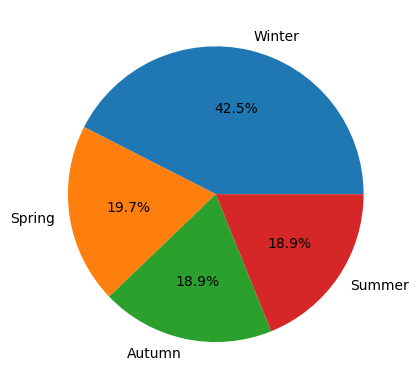

In [6]:
# Step 4: Visualize the distribution of key features
# Visualize season using a pie chart
season_wise_counts = df['season'].value_counts()
print(season_wise_counts)
plt.pie(x=season_wise_counts.values,labels=season_wise_counts.index,autopct='%1.1f%%')
plt.show()

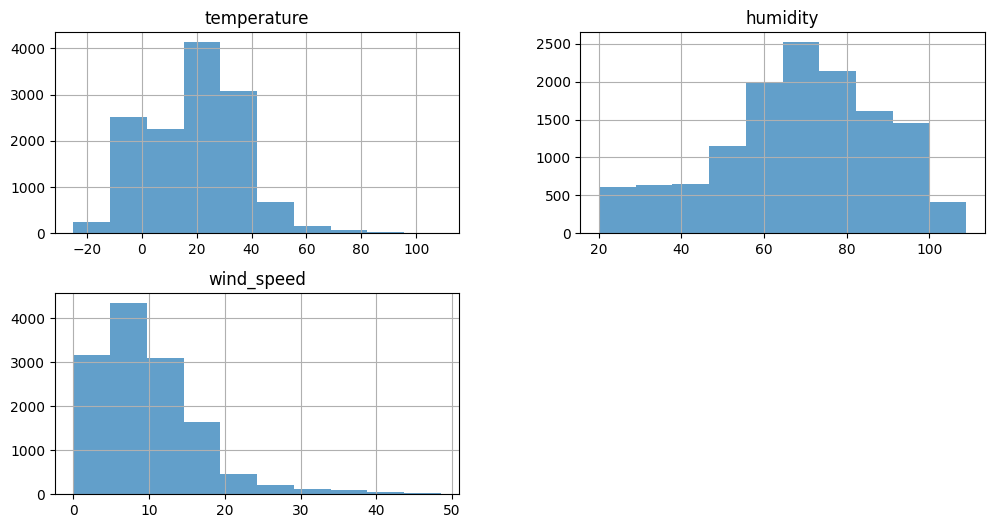

In [7]:
df[['temperature', 'humidity', 'wind_speed']].hist(bins=10, figsize=(12, 6), alpha=0.7)
plt.show()

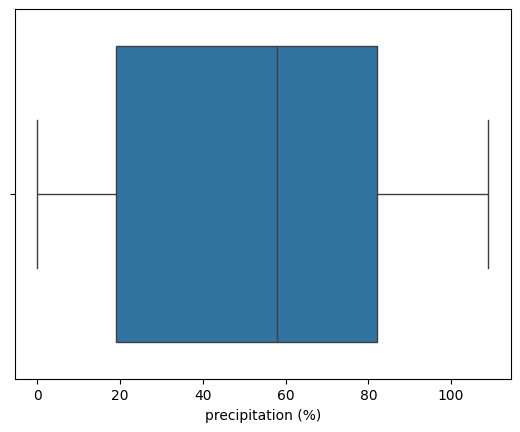

In [19]:
# Visualize precipitation (%) using a box plot
sns.boxplot(x=df['precipitation (%)'])
plt.show()

### Task 2: Data Transformation

1. Encode cloud_cover, location and season using one-hot encoding.
2. Scale the numerical features (temperature, humidity, wind_speed, precipitation (%), atmospheric_pressure, uv_index, visibility (km)) using StandardScaler.
3. Display the first few rows of the updated dataset.

In [9]:
# Step 1: Encode cloud_cover, location and season using one-hot encoding.



In [10]:
# Step 2: Scale the numerical features



In [11]:
# Step3: Display the first few rows of the updated dataset.



### Task 3: Model Training Using SVM with Linear Kernel

1. Select the features and the target variable for modeling.
2. Split the data into training and test sets with a test size of 30%.
3. Initialize and train an SVM model with a linear kernel using the training data.
4. Print the model's accuracy score on test data.
5. Evaluate the model using a classification report and confusion matrix.

In [12]:
# Step 1: Select features and target variable
X = df.drop(columns='weather_type')
y = df['weather_type']
# Step 2: Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train.head()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location
10163,24,75,17.5,84,overcast,999.76,3,Summer,5.0,mountain
12929,46,69,3.5,43,cloudy,842.22,12,Spring,5.5,inland
5735,24,87,18.0,65,partly cloudy,1011.48,1,Spring,1.5,inland
440,1,102,35.0,90,overcast,988.38,5,Winter,4.0,mountain
2018,42,87,17.5,100,partly cloudy,1016.17,8,Summer,8.0,inland


In [13]:
# Step 3: Train SVM with linear kernel
# Define preprocessing for categorical and numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['temperature', 'humidity', 'wind_speed', 'precipitation (%)',
       'atmospheric_pressure', 'uv_index',
       'visibility (km)']),  # Scale numerical features
        ('cat', OneHotEncoder(), ['cloud_cover','season','location'])          # One-hot encode categorical features
    ]
)

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),                  # Preprocessing step
    ('model',SVC(kernel='linear'))  # Model step
])


# Step 4: Print accuracy score
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

      Cloudy       0.86      0.85      0.85       955
       Rainy       0.87      0.87      0.87       982
       Snowy       0.88      0.94      0.91      1033
       Sunny       0.92      0.88      0.90       990

    accuracy                           0.89      3960
   macro avg       0.89      0.88      0.88      3960
weighted avg       0.89      0.89      0.88      3960



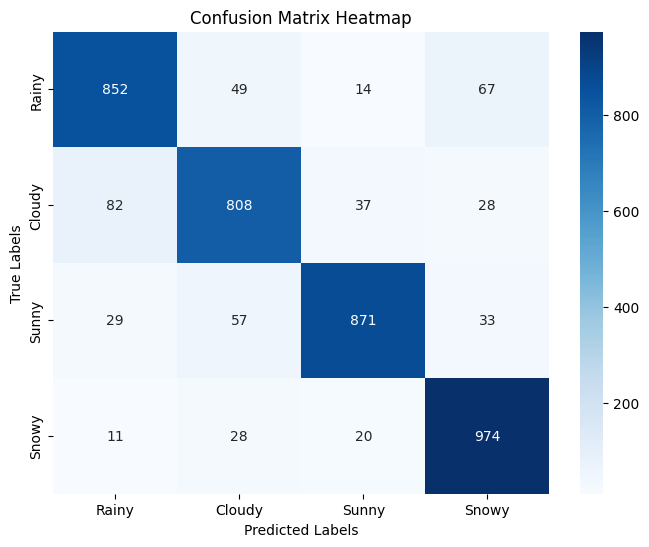

In [14]:
# Step 5: Evaluate the model


#classification report


#confusion matrix
labels=df['weather_type'].unique()
cm = confusion_matrix(y_test,y_pred,labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Task 4: Model Training Using SVM with RBF Kernel

1. Initialize and train an SVM model with an RBF kernel using the training data.
2. Print the model's accuracy score on test data.
3. Evaluate the model using a classification report and confusion matrix.

              precision    recall  f1-score   support

      Cloudy       0.86      0.88      0.87       955
       Rainy       0.89      0.90      0.89       982
       Snowy       0.94      0.94      0.94      1033
       Sunny       0.93      0.89      0.91       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



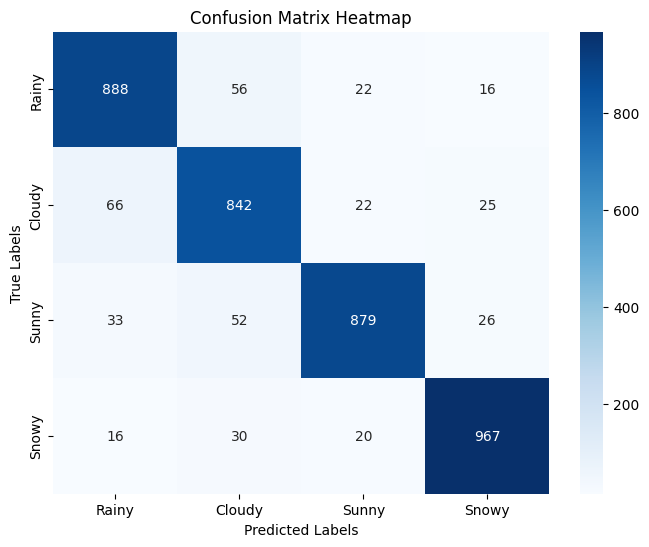

In [15]:
# Step 1: Train SVM with RBF kernel

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),                  # Preprocessing step
    ('model',SVC(kernel='rbf'))  # Model step
])


# Step 4: Print accuracy score
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

# Step 2: Print accuracy score




# Step 3: Evaluate the model

#classification report


#confusion matrix

cm = confusion_matrix(y_test,y_pred,labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Task 5: Experiment with Hyperparameters in SVM

1. Train an SVM model with an RBF kernel and the following hyperparameters:
    - C=0.5
    - gamma='auto'
    - kernel='rbf'
    - degree=2
      
Learn about these parameters here: [SVC Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

--------------------------------------------------------------------------------------------------------------------------------------------------------

2. Print the model's accuracy score on test data.
3. Evaluate the model using a classification report and confusion matrix.

              precision    recall  f1-score   support

      Cloudy       0.85      0.88      0.86       955
       Rainy       0.90      0.90      0.90       982
       Snowy       0.90      0.94      0.92      1033
       Sunny       0.95      0.87      0.91       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



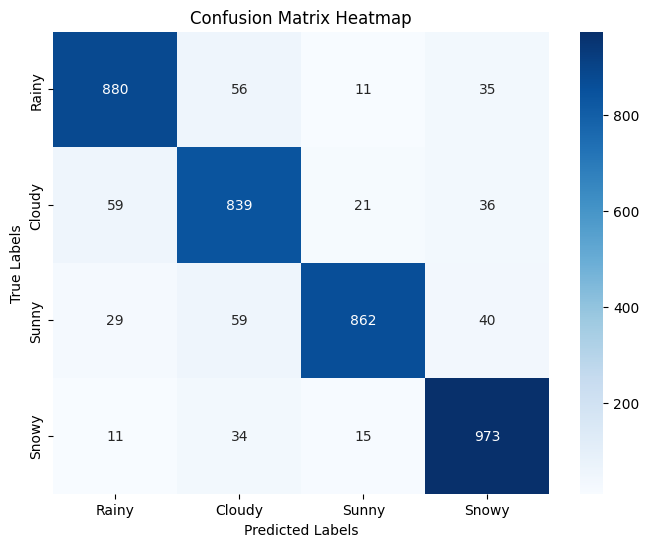

In [16]:
# Step 1: Train the SVM model with specified hyperparameters
pipeline.set_params(model__C=0.5, model__gamma='auto', model__degree=2)

# Step 2: Print the model's accuracy score
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)


# Step 3: Make predictions on the test set



# Step 4: Evaluate the model using a classification report and confusion matrix


#classification report



#confusion matrix

cm = confusion_matrix(y_test,y_pred,labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Task 6: Implementing Sklearn Pipeline

1. Create a pipeline that includes the StandardScaler and the SVM model with an RBF kernel.
2. Train the pipeline using the training data.
3. Evaluate the pipeline using the test data and print the classification report.

In [17]:
# Create a pipeline with two steps: scaling and SVM with RBF kernel


# Fit the pipeline on the training data


# Make predictions using the pipeline on the test data


# Print the classification report for the pipeline model


# Print the confusion matrix for the pipeline model
